# `vzw-entropy` — Van Zuylen & Willumsen's (1980) entropy-balancing OD estimation

**What.** `vzw-entropy` (T2, ADR-002) is the information-minimizing sibling
of `gls`: instead of a quadratic prior/count trade-off, it multiplicatively
balances each OD cell in log-space against every sensor's count via a damped
fixed-point iteration — an EXPONENT form, `g <- (c/p)^p` per sensor, not a
linear blend. It is the classical maximum-entropy / minimum-information
estimator (`biproportional fitting` lineage), a genuinely different
mathematical family from `gls`'s quadratic program.

**Why it is in the benchmark.** Entropy balancing predates `gls` in the OD
estimation literature and is still the default in several commercial
packages; its damped multiplicative update converges geometrically to a
DIFFERENT fixed point than a linear GLS blend whenever sensors disagree,
which this notebook makes an executable, hand-verified fact. See the
[model compendium](../../docs/MODELS.md) (Van Zuylen & Willumsen 1980) and
[docs/design/adr-002-t2-estimation-certificate.md](../../docs/design/adr-002-t2-estimation-certificate.md)
(P1).

**Scope.** The exact single-sensor exponent fixed point (one pass vs
converged), the damped multi-sensor compromise under mutually inconsistent
counts, and the Braess global-basin `D=6` recovery.

**Canon.** `[vanzuylen1980most]`, [docs/REFERENCES.md](../../docs/REFERENCES.md) / [docs/references.bib](../../docs/references.bib).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every
scored quantity below is recomputed live — the closed-form fixed points are
recomputed algebraically in-cell (no trusted digits), and the Braess recovery
is recomputed by the P1 `ODCertifier` from the emitted OD matrix against the
harness's own pinned BFW assignment, never from `vzw-entropy`'s self-report
([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `vzw-entropy` is a core estimator: a plain `pip install -e .`
# suffices — no optional extra, so no guard cell. The inline backend is
# Agg-based (headless CI renders into the notebook); NEVER
# matplotlib.use("Agg") in-kernel — it silently suppresses inline capture.
%matplotlib inline
import numpy as np

from tabench import (
    Budget,
    Demand,
    ODCertifier,
    RngBundle,
    Trace,
    VZWEntropyEstimator,
    braess_scenario,
    two_route_scenario,
    viz,
)
from tabench.core.rng import SOURCE_OBSERVATION
from tabench.estimation import ODTrace, vzw_balance
from tabench.estimation.base import EstimationTask
from tabench.models.frank_wolfe import BiconjugateFrankWolfeModel
from tabench.observe.levels import LinkCounts

BRAESS_TRUTH = np.array([4.0, 2.0, 2.0, 2.0, 4.0])  # UE(D=6), recomputed below
TWOROUTE_TRUTH = np.array([2.5, 2.5, 1.5, 1.5])  # UE(D=4), recomputed below

# Analytic anchors recomputed, never quoted: pin both by an independent
# high-precision BFW solve before EITHER constant is used as a data-generating
# truth anywhere below.
def _pinned_ue(scenario):
    trace = Trace()
    BiconjugateFrankWolfeModel().solve(
        scenario, Budget(iterations=5000, target_relative_gap=1e-10), RngBundle(0), trace
    )
    return trace.final.link_flows

np.testing.assert_allclose(_pinned_ue(braess_scenario(6.0)), BRAESS_TRUTH, atol=1e-6)
np.testing.assert_allclose(_pinned_ue(two_route_scenario(sue_theta=None)), TWOROUTE_TRUTH, atol=1e-6)

## The exponent fixed point: one pass vs geometric convergence

Single pair, single sensor on route A (`p_a = 2.5/4 = 0.625`, count `c=2.5`).
One damped pass gives `T = (c/p)^p`, NOT the linear-blend result `c/p` a
`gls`-style update would give in one step; the geometric limit over many
passes IS the exact fixed point `c/p = 4.0`.

In [2]:
p_a = TWOROUTE_TRUTH[0] / 4.0  # route-A proportion, recomputed
count = TWOROUTE_TRUTH[0]

best_g1, traj1, consistent1 = vzw_balance(
    np.array([1.0]), np.array([[p_a]]), np.array([count]), n_passes=1
)
print(f"one-pass estimate : {best_g1[0]:.6f}  (c/p)^p = {(count / p_a) ** p_a:.6f}")
assert np.isclose(best_g1[0], (count / p_a) ** p_a, atol=1e-12)
assert consistent1 is False  # one pass has not yet reached the fixed point
assert len(traj1) == 2  # prior + one update

best_g60, _, consistent60 = vzw_balance(
    np.array([1.0]), np.array([[p_a]]), np.array([count]), n_passes=60
)
print(f"60-pass estimate   : {best_g60[0]:.6f}  (fixed point c/p = {count / p_a:.6f})")
assert np.isclose(best_g60[0], count / p_a, atol=1e-9)
assert np.isclose(best_g60[0], 4.0, atol=1e-9)
assert consistent60 is True

one-pass estimate : 2.378414  (c/p)^p = 2.378414
60-pass estimate   : 4.000000  (fixed point c/p = 4.000000)


## Mutually inconsistent sensors: a damped compromise, not oscillation

Two sensors on the SAME pair, at odds (`c_a=3.0` on route A's proportion,
`c_b=1.0` on route B's) — no single demand satisfies both exactly. The
damped log-space update converges to a compromise fixed point, recomputed
here exactly via the sequential single-link recursion.

In [3]:
p_b = TWOROUTE_TRUTH[2] / 4.0  # route-B proportion, recomputed
c_a, c_b = 3.0, 1.0
best_g, _, consistent = vzw_balance(
    np.array([1.0]), np.array([[p_a], [p_b]]), np.array([c_a, c_b]), n_passes=400
)
# Sequential log-space fixed point of the two damped single-link updates
# x <- (1-p)*x + p*log(c/p), applied for sensor a then b:
t_a, t_b = np.log(c_a / p_a), np.log(c_b / p_b)
x_star = ((1 - p_b) * p_a * t_a + p_b * t_b) / (1 - (1 - p_a) * (1 - p_b))
print(f"compromise estimate : {best_g[0]:.6f}")
print(f"closed-form exp(x*) : {np.exp(x_star):.6f}")
assert np.isclose(best_g[0], np.exp(x_star), atol=1e-6)
assert consistent is False  # mutually inconsistent -> residual above tolerance

compromise estimate : 3.599232
closed-form exp(x*) : 3.599232


## Braess: global-basin recovery from `D=5.5`

`braess_scenario(6.0)` is the D=6 Braess network, frozen and content-hashed
(P2). From a prior `D=5.5` — inside the global basin (see
[`spiess`](02-spiess.ipynb) for the D=4 SPURIOUS-basin caveat this network
also has) — full noiseless sensors let `vzw-entropy` recover the true `D=6`.

In [4]:
sc = braess_scenario(6.0)
print(f"scenario      : {sc.name}")
print(f"content hash  : {sc.content_hash()[:16]}…")

prior_matrix = np.zeros((2, 2))
prior_matrix[0, 1] = 5.5
ds = LinkCounts(np.arange(5), 1, "none").observe(
    sc, BRAESS_TRUTH, RngBundle(0).generator(SOURCE_OBSERVATION)
)
task = EstimationTask(
    name="t", network=sc.network, prior=Demand(prior_matrix), dataset=ds,
    identifiability={}, scenario_hash=sc.content_hash(), seed=0,
)
trace = ODTrace()
VZWEntropyEstimator(k_inner=120, outer_iters=80).estimate(
    task, Budget(sp_calls=10**9, iterations=200), RngBundle(0), trace
)
recovered = trace.final.od_matrix[0, 1]
print(f"recovered D : {recovered:.4f}  (truth: 6.0, off prior: 5.5)")
assert abs(recovered - 6.0) < 1e-3

certifier = ODCertifier(
    sc, np.arange(5), np.array([], dtype=np.int64),
    BRAESS_TRUTH[None, :], BRAESS_TRUTH[[]][None, :], BRAESS_TRUTH,
    {"linear_identifiable": True},
)
metrics = certifier.certify(trace.final.od_matrix)
print(f"certified od_rmse : {metrics['od_rmse']:.4e}")
assert metrics["od_feasible"] == 1.0
assert metrics["od_rmse"] < 1e-3

scenario      : braess
content hash  : cf00f411cdccec88…
recovered D : 6.0000  (truth: 6.0, off prior: 5.5)
certified od_rmse : 0.0000e+00


## Visualize

`tabench.viz` draws the road `Network`'s link flows for the recovered
Braess demand against the truth (the same certified OD matrix from the cell
above, re-assigned).

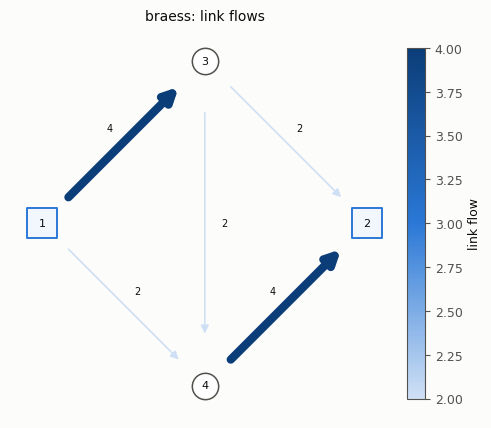

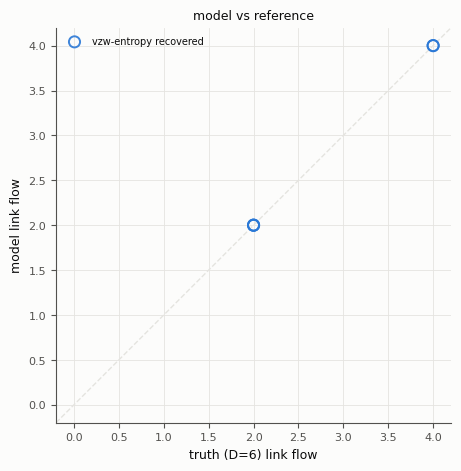

In [5]:
recovered_matrix = trace.final.od_matrix
from tabench import Scenario
recovered_trace = Trace()
BiconjugateFrankWolfeModel().solve(
    Scenario("recovered", sc.network, Demand(recovered_matrix), family=sc.family),
    Budget(iterations=5000, target_relative_gap=1e-10), RngBundle(0), recovered_trace,
)
display(viz.plot_network_flows(sc.network, BRAESS_TRUTH))
display(viz.plot_flow_scatter(
    ("truth (D=6)", BRAESS_TRUTH),
    {"vzw-entropy recovered": recovered_trace.final.link_flows},
))

## Takeaways & pointers

- **Certified, not self-reported.** The Braess `od_rmse` above came from
  `ODCertifier`'s own re-assignment of the emitted OD matrix, never from
  `vzw-entropy`'s internal proportions.
- **The exponent form is distinctive.** One damped pass gives `(c/p)^p`, not
  a linear `gls`-style blend — verified exactly above, not asserted.
- **Where next.** the quadratic-tradeoff sibling on the SAME network
  [`gls`](01-gls.ipynb); the count-only end of the spectrum
  [`spiess`](02-spiess.ipynb); the lineage in the
  [model compendium](../../docs/MODELS.md).